# Trading

The purpose of this worksheet is to demonstrate and describe how trading works in OSEM.

## Table of contents

1. [What trading does](#section-1)
2. [Setting up a run](#section-2)
3. [The projection loop](#section-3)
4. [Trading period by period](#section-4)
    - [What was traded and when](#traded-what)
    - [How much was traded](#traded-how-much)
5. [Checks](#section-5)
    - [Cash is swept to zero](#cash-swept)
    - [Trading does not create or destroy value](#value-neutral)

<a id="section-1"></a>

## 1. What trading does

OSEM holds cash in a single bank account. Over a period that account collects the dividends,
coupons and matured notionals the portfolio paid out, and is drained by the liability outflows
the company committed to. At the end of the period the balance is almost never zero, and
`trade` in `MainLoop.py` puts it back to zero by resizing the portfolio.

The rule is **proportional**: every position is scaled by the same factor, so the asset
allocation is preserved and only the size of the portfolio changes. Writing $C$ for the bank
balance and $MV$ for the market value of the portfolio at that moment:

 * if $C > 0$ the surplus buys more of everything, each position scaled by $1 + C/MV$
 * if $C < 0$ the deficit is covered by selling, each position scaled by $1 - \min(1, -C/MV)$
 * if $MV \leq 0$ there is nothing to trade and the balance is left alone

The bank account is then credited with the market value that left the portfolio, or debited with
the value that entered it:

$$ C^{after} = C^{before} + MV^{before} - MV^{after} $$

Both branches therefore drive the balance to zero, and the total of cash plus portfolio is
unchanged by the trade itself. The one exception is a deficit larger than the whole portfolio:
the sell fraction is capped at 1, everything is sold, and the account stays negative.

Note what trading does **not** do: it never changes the mix between equities and bonds, and it
never picks individual assets. Rebalancing towards a target allocation is not modelled.

<a id="section-2"></a>

## 2. Setting up a run

The same inputs `main.py` builds before entering its loop.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys

base_folder = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "ALM.ini").is_file())
sys.path.insert(0, str(base_folder / "src"))
os.chdir(base_folder)
from osem.ImportData import get_configuration, get_settings, import_SWEiopa, get_cash, get_equity_share,get_corporate_bonds, get_liability
from osem.ConfigurationClass import Configuration
from osem.CurvesClass import Curves
from osem.BondClasses import CorpBondPortfolio
from osem.EquityClasses import EquitySharePortfolio
from osem.MainLoop import (create_cashflow_dataframe, create_liabilities_df, set_dates_of_interest,
                           process_expired_cf, process_expired_liab, trade,
                           find_terminated_positions, liquidate_positions,
                           portfolio_market_value)

In [2]:
base_folder = os.getcwd()  # Get current working directory
conf: Configuration
conf = get_configuration(os.path.join(base_folder, "ALM.ini"), os)

In [3]:
parameters_file = conf.input_parameters
cash_portfolio_file = conf.input_cash_portfolio
equity_portfolio_file = conf.input_equity_portfolio
liability_cashflow_file = conf.input_liability_cashflow
bond_portfolio_file = conf.input_bond_portfolio

In [4]:
settings = get_settings(parameters_file)

In [5]:
[maturities_country, curve_country, extra_param, Qb] =  import_SWEiopa(settings.EIOPA_param_file,
                                                                          settings.EIOPA_curves_file, settings.country)

Curves object with information about term structure:

In [6]:
curves = Curves(extra_param["UFR"] / 100, settings.precision, settings.tau, settings.modelling_date,
                    settings.country)

In [7]:
curves.set_observed_term_structure(maturity_vec=curve_country.index.to_numpy(dtype=float), yield_vec=curve_country.values)
curves.calc_fwd_rates()
curves.project_forward_rate(settings.n_proj_years+1)
curves.calibrate_projected(settings.n_proj_years+1, 0.05, 0.5, 1000)

Cash, equities and bonds:

In [8]:
cash = get_cash(cash_portfolio_file)

In [9]:
equity_input_generator = get_equity_share(equity_portfolio_file) # Create generator that contains all equity positions
eq_input = {equity_share.asset_id: equity_share for equity_share in equity_input_generator}

In [10]:
bond_input_generator = get_corporate_bonds(bond_portfolio_file)
bond_input = {corp_bond.asset_id: corp_bond for corp_bond in bond_input_generator}

In [11]:
eq_ptf = EquitySharePortfolio(eq_input)
bd_ptf = CorpBondPortfolio(bond_input)

In [12]:
div_dict = eq_ptf.create_dividend_flows(settings.modelling_date, settings.end_date)
ter_dict = eq_ptf.create_terminal_flows(modelling_date=settings.modelling_date,
                                                            terminal_date=settings.end_date,
                                                            terminal_rate=curves.ufr)
cpn_flows = bd_ptf.create_coupon_flows(settings.modelling_date, settings.end_date)
not_flows = bd_ptf.create_maturity_flows(terminal_date=settings.end_date)

In [13]:
unique_div_dates = eq_ptf.unique_dates_profile(div_dict)
unique_ter_dates = eq_ptf.unique_dates_profile(ter_dict)
unique_cpn_dates = bd_ptf.unique_dates_profile(cpn_flows)
unique_not_dates = bd_ptf.unique_dates_profile(not_flows)

In [14]:
liabilities = get_liability(liability_cashflow_file)
unique_liabilities_dates = liabilities.unique_dates_profile()

In [15]:
[eq_price_df, eq_growth_df, eq_units_df] = eq_ptf.init_equity_portfolio_to_dataframe(settings.modelling_date)
[bd_price_df, bd_zspread_df, bd_units_df] = bd_ptf.init_bond_portfolio_to_dataframe(settings.modelling_date)
bank_account = pd.DataFrame(data=[cash.bank_account], columns=[settings.modelling_date])

In [16]:
div_df = create_cashflow_dataframe(div_dict, unique_div_dates)
ter_df = create_cashflow_dataframe(ter_dict, unique_ter_dates)
cpn_df = create_cashflow_dataframe(cpn_flows, unique_cpn_dates)
not_df = create_cashflow_dataframe(not_flows, unique_not_dates)
liab_df = create_liabilities_df(liabilities)

In [17]:
dates_of_interest = set_dates_of_interest(settings.modelling_date, settings.end_date)
previous_date = settings.modelling_date
proj_period = 0

In [18]:
bd_zspread_df = bd_ptf.calibrate_bond_portfolio(bd_zspread_df, settings, proj_period, curves)

C:\Users\grego\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
C:\Users\grego\OneDrive\Documenti\GitHub\Open_Source_Economic_Model\src\osem\BondClasses.py:241: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  disc_value: float = float(np.sum(nodisc_value))


<a id="section-3"></a>

## 3. The projection loop

The same sequence `main.py` runs, with the state around each `trade` call recorded so the
trading itself can be looked at afterwards.

Two details matter for the numbers to come out right:

 * positions whose terminal value has just been paid out are **liquidated** before trading.
   Without that step the cash is credited to the bank account while the position is still in the
   portfolio, `trade` reinvests it, and the same money is counted twice. Leaving it out inflates
   the closing portfolio by roughly half.
 * the bond repricing is done at projection year `proj_period + 1`, because `proj_period` counts
   *completed* periods while `current_date` is one year further on.

In [19]:
trading_log = []

for current_date in dates_of_interest.values:
    eq_units_df[current_date] = eq_units_df[previous_date]
    bd_units_df[current_date] = bd_units_df[previous_date]
    bank_account[current_date] = bank_account[previous_date]

    time_frac = (current_date - previous_date).days / 365.25

    # ---- cash flows that expired during the period ----
    expired_cash, div_df, unique_div_dates = process_expired_cf(unique_div_dates, current_date, div_df, eq_units_df)
    bank_account[current_date] += expired_cash

    expired_cash, cpn_df, unique_cpn_dates = process_expired_cf(unique_cpn_dates, current_date, cpn_df, bd_units_df)
    bank_account[current_date] += expired_cash

    terminated_eq_ids = find_terminated_positions(unique_ter_dates, current_date, ter_df)
    expired_cash, ter_df, unique_ter_dates = process_expired_cf(unique_ter_dates, current_date, ter_df, eq_units_df)
    bank_account[current_date] += expired_cash

    matured_bd_ids = find_terminated_positions(unique_not_dates, current_date, not_df)
    expired_cash, not_df, unique_not_dates = process_expired_cf(unique_not_dates, current_date, not_df, bd_units_df)
    bank_account[current_date] += expired_cash

    expired_cash, liab_df, unique_liabilities_dates = process_expired_liab(unique_liabilities_dates, current_date, liab_df)
    bank_account[current_date] -= expired_cash

    # ---- asset growth and repricing ----
    eq_price_df[current_date] = eq_price_df[previous_date] * (
            1 + eq_growth_df[settings.modelling_date]) ** time_frac

    bd_price_df[current_date] = bd_price_df[previous_date]
    bd_price_df = bd_ptf.price_bond_portfolio(cpn_df, not_df, settings, proj_period + 1, curves,
                                              bd_zspread_df, bd_price_df, current_date)

    # ---- close out positions whose terminal value has been paid ----
    eq_units_df = liquidate_positions(eq_units_df, terminated_eq_ids, current_date)
    bd_units_df = liquidate_positions(bd_units_df, matured_bd_ids, current_date)

    # ---- trade, recording the state either side of it ----
    cash_before = float(bank_account[current_date].iloc[0])
    mv_before = portfolio_market_value(eq_price_df, eq_units_df, bd_price_df, bd_units_df, current_date)
    eq_units_before = float(eq_units_df[current_date].sum())
    bd_units_before = float(bd_units_df[current_date].sum())

    eq_units_df, bd_units_df, bank_account = trade(
        current_date, bank_account, eq_units_df, eq_price_df, bd_units_df, bd_price_df)

    cash_after = float(bank_account[current_date].iloc[0])
    mv_after = portfolio_market_value(eq_price_df, eq_units_df, bd_price_df, bd_units_df, current_date)

    trading_log.append({
        "Date": current_date,
        "Cash before": cash_before,
        "Market value before": mv_before,
        # No portfolio left to trade against is its own case, not a buy
        "Action": ("None" if mv_before <= 0 else
                   "Buy" if cash_before > 0 else
                   "Sell" if cash_before < 0 else "None"),
        "Traded fraction": (mv_after / mv_before - 1) if mv_before > 0 else 0.0,
        "Equity units before": eq_units_before,
        "Equity units after": float(eq_units_df[current_date].sum()),
        "Bond units before": bd_units_before,
        "Bond units after": float(bd_units_df[current_date].sum()),
        "Cash after": cash_after,
        "Market value after": mv_after,
    })

    previous_date = current_date
    proj_period += 1

trading_log = pd.DataFrame(trading_log).set_index("Date")

C:\Users\grego\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
C:\Users\grego\OneDrive\Documenti\GitHub\Open_Source_Economic_Model\src\osem\BondClasses.py:241: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  disc_value: float = float(np.sum(nodisc_value))
C:\Users\grego\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
C:\Users\grego\OneDrive\Documenti\GitH

<a id="section-4"></a>

## 4. Trading period by period

<a id="traded-what"></a>

### What was traded and when

Each row is one period: the balance the period ended with before trading, the direction that
implies, and what the portfolio looked like either side of the trade.

***

In [20]:
display(trading_log[["Cash before", "Market value before", "Action",
                     "Traded fraction", "Cash after", "Market value after"]].head(12))

print(trading_log["Action"].value_counts().to_string())

,Cash before,Market value before,Action,Traded fraction,Cash after,Market value after
Date,,,,,,
2024-04-29,124278.520563,6.187095e+05,Buy,0.200867,4.365575e-11,7.429880e+05
2025-04-29,29673.856319,7.585788e+05,Buy,0.039118,-1.236913e-10,7.882526e+05
2026-04-29,165951.144743,6.652482e+05,Buy,0.249457,-2.910383e-11,8.311994e+05
2027-04-29,203638.903852,6.735712e+05,Buy,0.302327,5.820766e-11,8.772101e+05
2028-04-29,35660.384235,8.961911e+05,Buy,0.039791,-1.600711e-10,9.318515e+05
2029-04-29,269947.150355,7.141020e+05,Buy,0.378023,1.164153e-10,9.840491e+05
2030-04-29,37293.812612,1.007107e+06,Buy,0.037031,0.000000e+00,1.044401e+06
2031-04-29,78769.736856,1.029244e+06,Buy,0.076532,0.000000e+00,1.108014e+06
2032-04-29,43420.725727,1.134854e+06,Buy,0.038261,9.458745e-11,1.178275e+06


Action
Buy     49
None     1


***

The unit columns show the proportional rule at work. Every position is scaled by the same
factor, so the equity and bond unit totals move by the same percentage:

***

In [21]:
units_view = trading_log[["Equity units before", "Equity units after",
                          "Bond units before", "Bond units after", "Traded fraction"]].copy()
units_view["Equity change"] = (units_view["Equity units after"]
                               / units_view["Equity units before"] - 1)
units_view["Bond change"] = (units_view["Bond units after"]
                             / units_view["Bond units before"] - 1)

display(units_view[["Equity change", "Bond change", "Traded fraction"]].head(12))

,Equity change,Bond change,Traded fraction
Date,,,
2024-04-29,0.200867,0.200867,0.200867
2025-04-29,0.039118,0.039118,0.039118
2026-04-29,0.249457,0.249457,0.249457
2027-04-29,0.302327,0.302327,0.302327
2028-04-29,0.039791,0.039791,0.039791
2029-04-29,0.378023,0.378023,0.378023
2030-04-29,0.037031,0.037031,0.037031
2031-04-29,0.076532,0.076532,0.076532
2032-04-29,0.038261,0.038261,0.038261


***

<a id="traded-how-much"></a>

### How much was traded

***

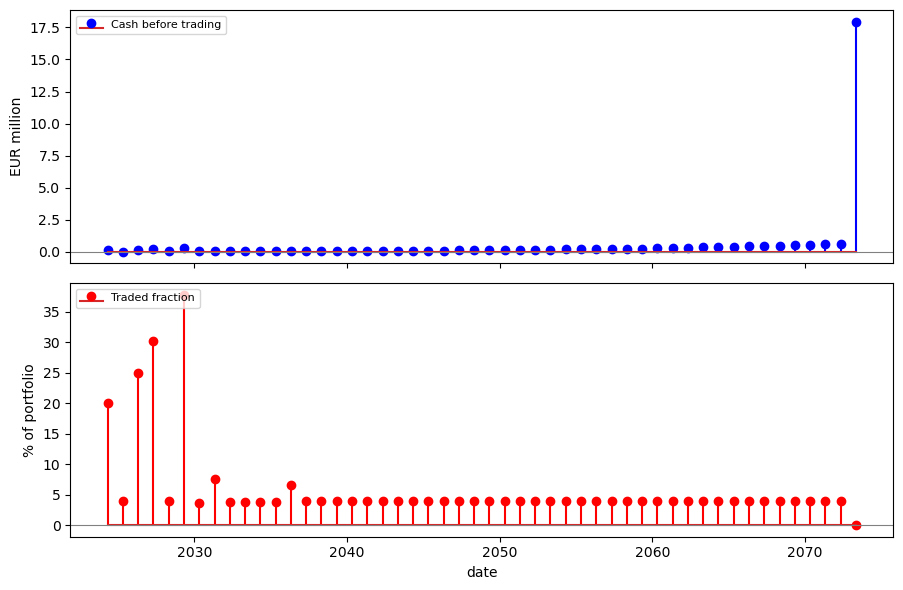

In [22]:
fig, (ax1, ax2) = plt.subplots(2, figsize=(9, 6), sharex=True)

ax1.stem(trading_log.index, trading_log["Cash before"] / 1e6, linefmt="b", label="Cash before trading")
ax1.axhline(0, color="grey", linewidth=0.8)
ax1.set_ylabel("EUR million")
ax1.legend(loc="upper left", fontsize=8)

ax2.stem(trading_log.index, trading_log["Traded fraction"] * 100, linefmt="r", label="Traded fraction")
ax2.axhline(0, color="grey", linewidth=0.8)
ax2.set_ylabel("% of portfolio")
ax2.set_xlabel("date")
ax2.legend(loc="upper left", fontsize=8)

fig.tight_layout()
plt.show()

***

The two panels are the same quantity seen twice: the traded fraction is just the cash balance
divided by the portfolio it is spread across. Early periods trade a large share of a small
portfolio; later ones trade a small share of a large one.

<a id="section-5"></a>

## 5. Checks

<a id="cash-swept"></a>

### Cash is swept to zero

Trading exists to clear the bank account, so the balance after it should be zero in every
period where there is a portfolio to trade against. The final period is the exception: by then
every position has been liquidated, market value is zero, and the third branch of the rule
leaves the proceeds sitting in cash.

***

In [23]:
# trade() only acts when there is a portfolio to resize. In the final period every position
# has been liquidated, so market value before trading is zero, the MV <= 0 branch is taken and
# the balance is left alone. That period is excluded here and reported on its own.
tradable = trading_log["Market value before"] > 0
cash_left = trading_log.loc[tradable, "Cash after"].abs()

print(f"Periods with a portfolio to trade : {int(tradable.sum())} of {len(trading_log)}")
print(f"Max |cash| left after trading     : {cash_left.max():.3e}")
print()

if (cash_left < 1e-6).all():
    print("PASSED - every tradable period ends with an empty bank account")
else:
    print("FAILED - cash left after trading in:")
    display(trading_log.loc[tradable & (trading_log["Cash after"].abs() >= 1e-6),
                            ["Cash before", "Market value before", "Cash after"]])

assert (cash_left < 1e-6).all()

Periods with a portfolio to trade : 49 of 50
Max |cash| left after trading     : 2.095e-09

PASSED - every tradable period ends with an empty bank account


***

<a id="value-neutral"></a>

### Trading does not create or destroy value

A trade moves value between the bank account and the portfolio, so the two together must be
unchanged across the call:

$$ C^{before} + MV^{before} = C^{after} + MV^{after} $$

***

In [24]:
value_check = (trading_log["Cash before"] + trading_log["Market value before"]
               - trading_log["Cash after"] - trading_log["Market value after"])
scale = (trading_log["Cash before"].abs() + trading_log["Market value before"].abs())

print(f"Max |residual|          : {value_check.abs().max():.3e}")
print(f"Max relative residual   : {(value_check / scale).abs().max():.3e}")
print()

if (value_check / scale).abs().max() < 1e-12:
    print("PASSED - trading is value neutral")
else:
    print("FAILED - value created or destroyed by trading:")
    display(pd.DataFrame({"Residual": value_check[(value_check / scale).abs() >= 1e-12]}))

assert (value_check / scale).abs().max() < 1e-12

Max |residual|          : 9.313e-10
Max relative residual   : 2.100e-16

PASSED - trading is value neutral


***

The closing position, for comparison with a full `main.py` run:

***

In [25]:
closing = pd.DataFrame({"Value": [
    float(bank_account[previous_date].iloc[0]),
    portfolio_market_value(eq_price_df, eq_units_df, bd_price_df, bd_units_df, previous_date),
]}, index=["End cash", "End market value"])
closing.loc["Total"] = closing["Value"].sum()

display(closing)

,Value
End cash,1.796058e+07
End market value,0.000000e+00
Total,1.796058e+07


***